<a href="https://colab.research.google.com/github/prithviemmidi/LifeSatisfactionAnalysis/blob/main/Decision_Tree_Modelling_%2B_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install cubist pystout factor_analyzer linearmodels --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 2.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.0/594.0 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.5 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
import io
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.tree import DecisionTreeClassifier as dtc
from sklearn.tree import DecisionTreeRegressor as dtr
from sklearn.tree import plot_tree
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error
from linearmodels.panel import PanelOLS, PooledOLS
from sklearn.linear_model import LinearRegression
from cubist import Cubist
from pystout import pystout
from sklearn.model_selection import ParameterGrid
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
import seaborn as sns
import os

Mounted at /content/drive


In [3]:
path = "/content/drive/MyDrive/lifesat_csv.csv"
df_old = pd.read_csv(path)
df_old.head()

,pidp,agenew,incomecpi,male,neduc,ueduc,oheduc,Alevel,gcse,otheduc,...,member34,othersize,pomst,agesq,openness_std,neuroticism_std,agreeableness_std,extraversion_std,conscientiousness_std,yearid
0,68035365,45,1981.589,1,0,0,0,0,0,1,...,0,0,0.00000,2025,1.134772,1.7147,1.33485,0.318156,-0.471428,1
1,68035365,46,2110.081,1,0,0,0,0,0,1,...,0,0,33.33333,2116,1.134772,1.7147,1.33485,0.318156,-0.471428,2
2,68035365,46,2351.826,1,0,0,0,0,0,1,...,0,0,66.66666,2116,1.134772,1.7147,1.33485,0.318156,-0.471428,3
3,68035365,48,2219.140,1,0,0,0,0,0,1,...,0,0,66.66666,2304,1.134772,1.7147,1.33485,0.318156,-0.471428,4
4,68035365,49,2498.854,1,0,0,0,0,0,1,...,0,0,50.00000,2401,1.134772,1.7147,1.33485,0.318156,-0.471428,5


In [4]:
df_old["incomecpi"] = pd.to_numeric(df_old["incomecpi"], errors="coerce")

x = df_old["incomecpi"]

df_old["lincome"] = np.where(
    x == 0,
    0,
    np.where(
        (x > 0) & (x < 1),
        np.log(x + 1),
        np.where(x >= 1, np.log(x), np.nan)))

df_old["lincome_sq"] = df_old["lincome"] ** 2

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


aggregate rules

In [5]:
edu_cols = ['neduc','ueduc','oheduc','Alevel','gcse','otheduc']
marital_cols = ['single','married','others']
employment_cols = ['selfemploy','employed','unemploy','retired','sick','familycare','student']
household_cols = ['onemember','twomember','member34','othersize']
trait_cols = [
    'openness_std','neuroticism_std','agreeableness_std',
    'extraversion_std','conscientiousness_std']

In [6]:
agg_rules = {}

for col in df_old.columns:
    if col == 'pidp':
        continue
    elif col in ['male'] + trait_cols:
        agg_rules[col] = 'first'
    elif col in edu_cols:
        agg_rules[col] = 'max'
    else:
        agg_rules[col] = 'mean'

df = df_old.groupby('pidp').agg(agg_rules).reset_index()

print(f"Original rows in df_old: {len(df_old)}")
print(f"Unique individuals in df: {len(df)}")

Original rows in df_old: 25128
Unique individuals in df: 1047




```
Sorting into categorical variables
```



In [7]:
df["genders"] = df["male"].map({0: "Female", 1: "Male"})
df['marital_status'] = df[['single','married','others']].idxmax(axis=1)
df['employment_status'] = df[['selfemploy','employed','unemploy','retired','sick','familycare','student']].idxmax(axis=1)
df['household_size'] = df[['onemember','twomember','member34','othersize']].idxmax(axis=1)

In [8]:
df['education'] = df[['neduc','ueduc','oheduc','Alevel','gcse','otheduc']].idxmax(axis=1)
education_labels = {
    'neduc': 'None',
    'gcse': 'GCSE',
    'Alevel': 'A-level',
    'otheduc': 'Other ',
    'ueduc': 'University',
    'oheduc': 'Other Higher'}
df['education'] = df['education'].map(education_labels)

In [9]:
traits = [
    'openness_std',
    'neuroticism_std',
    'agreeableness_std',
    'extraversion_std',
    'conscientiousness_std']

In [10]:
df.head()

,pidp,agenew,incomecpi,male,neduc,ueduc,oheduc,Alevel,gcse,otheduc,...,extraversion_std,conscientiousness_std,yearid,lincome,lincome_sq,genders,marital_status,employment_status,household_size,education
0,68035365,57.041667,2493.496375,1,0,0,0,0,0,1,...,0.318156,-0.471428,12.5,7.793500,60.797778,Male,others,employed,onemember,Other
1,68058485,64.291667,4008.875375,1,0,0,0,0,1,0,...,-0.449034,-0.471428,12.5,8.152248,66.704068,Male,married,retired,twomember,GCSE
2,68058489,64.291667,4008.875375,0,0,0,0,0,0,1,...,-0.449034,-0.471428,12.5,8.152248,66.704068,Female,married,retired,twomember,Other
3,68064609,57.291667,4231.804125,0,0,0,0,0,1,0,...,1.085346,1.368915,12.5,8.226963,67.930656,Female,married,employed,twomember,GCSE
4,68097245,58.791667,1964.208062,0,0,0,0,0,1,0,...,1.852535,-0.471428,12.5,7.398608,55.095662,Female,others,employed,onemember,GCSE


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1047 entries, 0 to 1046
Data columns (total 39 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   pidp                   1047 non-null   int64  
 1   agenew                 1047 non-null   float64
 2   incomecpi              1047 non-null   float64
 3   male                   1047 non-null   int64  
 4   neduc                  1047 non-null   int64  
 5   ueduc                  1047 non-null   int64  
 6   oheduc                 1047 non-null   int64  
 7   Alevel                 1047 non-null   int64  
 8   gcse                   1047 non-null   int64  
 9   otheduc                1047 non-null   int64  
 10  single                 1047 non-null   float64
 11  married                1047 non-null   float64
 12  others                 1047 non-null   float64
 13  selfemploy             1047 non-null   float64
 14  employed               1047 non-null   float64
 15  unem

In [12]:
df.describe()

,pidp,agenew,incomecpi,male,neduc,ueduc,oheduc,Alevel,gcse,otheduc,...,pomst,agesq,openness_std,neuroticism_std,agreeableness_std,extraversion_std,conscientiousness_std,yearid,lincome,lincome_sq
count,1.047000e+03,1047.000000,1047.000000,1047.000000,1047.000000,1047.000000,1047.000000,1047.000000,1047.000000,1047.000000,...,1047.000000,1047.000000,1047.000000,1047.000000,1047.000000,1047.000000,1047.000000,1047.0,1047.000000,1047.000000
mean,4.254653e+08,52.281797,4085.248531,0.436485,0.115568,0.233047,0.134670,0.241643,0.313276,0.119389,...,70.675476,2915.440823,-0.007413,-0.018481,-0.050689,-0.013047,0.048860,12.5,8.096578,66.090118
std,2.434545e+08,11.194397,2062.525185,0.496186,0.319859,0.422974,0.341534,0.428283,0.464047,0.324400,...,12.384463,1189.712462,0.947431,0.970993,0.968454,0.993709,0.919850,0.0,0.511905,8.139293
min,6.803536e+07,29.833333,696.105387,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,15.277780,947.500000,-2.727849,-1.783065,-4.550178,-2.750603,-3.231943,12.5,6.293121,41.466080
25%,2.053444e+08,43.791667,2680.394821,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.888889,1976.208333,-0.410277,-1.083512,-0.626826,-0.449034,-0.471428,12.5,7.788931,60.939247
50%,4.097122e+08,51.791667,3806.917375,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,72.916665,2740.875000,0.362247,-0.383959,0.354012,0.318156,0.448744,12.5,8.150273,66.680306
75%,6.154190e+08,60.791667,4980.267125,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,79.166670,3754.125000,0.362247,0.315594,0.354012,0.318156,0.448744,12.5,8.443723,71.483323
max,8.200304e+08,83.875000,18702.897917,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,97.916668,7095.041667,1.907296,2.414253,1.334850,1.852535,1.368915,12.5,9.513765,90.573277


life satisfaction analysis

In [13]:
df['pomst'].describe()

,pomst
count,1047.000000
mean,70.675476
std,12.384463
min,15.277780
25%,63.888889
50%,72.916665
75%,79.166670
max,97.916668


In [14]:
pomst_table = df['pomst'].value_counts()
pomst_table

,count
pomst,
79.166670,11
81.250005,9
80.555560,9
78.472225,8
81.250004,8
...,...
83.333338,1
70.833336,1
73.611113,1


In [15]:
df['incomecpi'].describe()

,incomecpi
count,1047.000000
mean,4085.248531
std,2062.525185
min,696.105387
25%,2680.394821
50%,3806.917375
75%,4980.267125
max,18702.897917


factor analysis

In [16]:
df_fa = df[traits + ["male", "pomst"]].dropna().copy()
df_fa1 = df[traits].dropna()

In [17]:
# Suitability tests
chi2, p = calculate_bartlett_sphericity(df_fa1)
kmo_all, kmo_model = calculate_kmo(df_fa1)
print("=== Option 1: Big Five only ===")
print(f"Bartlett's test: chi2={chi2:.2f}, p={p:.4f}")
print(f"KMO score: {kmo_model:.3f}")
print("(KMO > 0.6 and Bartlett p < 0.05 suggest FA is appropriate)\n")

=== Option 1: Big Five only ===
Bartlett's test: chi2=356.40, p=0.0000
KMO score: 0.660
(KMO > 0.6 and Bartlett p < 0.05 suggest FA is appropriate)



In [18]:
# Correlation matrix
corr_matrix = df_fa1[traits].corr()
print(corr_matrix)

# Bartlett's test
chi_square_value, p_value = calculate_bartlett_sphericity(df_fa1[traits])
print("Bartlett's test chi-square:", chi_square_value)
print("Bartlett's test p-value:", p_value)

# KMO test
kmo_all, kmo_model = calculate_kmo(df_fa1[traits])
print("KMO overall:", kmo_model)

                       openness_std  neuroticism_std  agreeableness_std  \
openness_std               1.000000        -0.078207           0.218126   
neuroticism_std           -0.078207         1.000000          -0.079038   
agreeableness_std          0.218126        -0.079038           1.000000   
extraversion_std           0.250190        -0.210500           0.183520   
conscientiousness_std      0.178012        -0.140067           0.329575   

                       extraversion_std  conscientiousness_std  
openness_std                   0.250190               0.178012  
neuroticism_std               -0.210500              -0.140067  
agreeableness_std              0.183520               0.329575  
extraversion_std               1.000000               0.227835  
conscientiousness_std          0.227835               1.000000  
Bartlett's test chi-square: 356.4008465383538
Bartlett's test p-value: 1.7448822638655836e-70
KMO overall: 0.6596624578989464


In [19]:
# Correlation matrix
corr_matrix1 = df[traits + ['pomst']].corr()
print(corr_matrix1)

                       openness_std  neuroticism_std  agreeableness_std  \
openness_std               1.000000        -0.078207           0.218126   
neuroticism_std           -0.078207         1.000000          -0.079038   
agreeableness_std          0.218126        -0.079038           1.000000   
extraversion_std           0.250190        -0.210500           0.183520   
conscientiousness_std      0.178012        -0.140067           0.329575   
pomst                      0.094247        -0.414592           0.150816   

                       extraversion_std  conscientiousness_std     pomst  
openness_std                   0.250190               0.178012  0.094247  
neuroticism_std               -0.210500              -0.140067 -0.414592  
agreeableness_std              0.183520               0.329575  0.150816  
extraversion_std               1.000000               0.227835  0.181703  
conscientiousness_std          0.227835               1.000000  0.176784  
pomst                   

In [20]:
# Scree plot to decide number of factors
fa_scree1 = FactorAnalyzer(n_factors=5, rotation=None)
fa_scree1.fit(df_fa1)
ev1, v1 = fa_scree1.get_eigenvalues()


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


/tmp/ipykernel_1378/4237068448.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


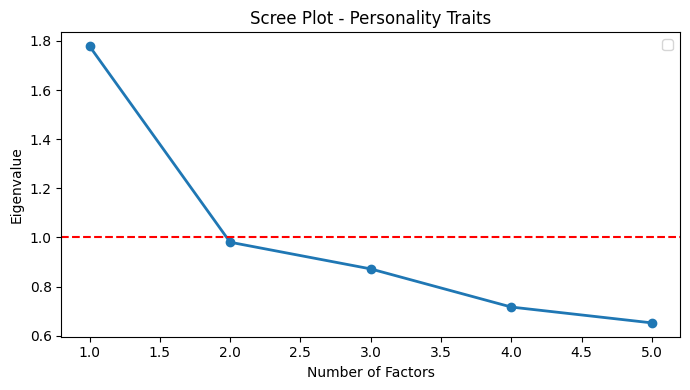

In [21]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, 6), ev1[:5], 'o-', linewidth=2)
plt.axhline(1, color='red', linestyle='--')
plt.xlabel('Number of Factors')
plt.ylabel('Eigenvalue')
plt.title('Scree Plot - Personality Traits')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
print(ev1)

[1.77883844 0.98055811 0.87190179 0.71660104 0.65210062]


1 factor model

In [23]:
n_factors1 = 1
fa1 = FactorAnalyzer(n_factors=n_factors1, rotation=None)
fa1.fit(df_fa[traits])

loadings1 = pd.DataFrame(
    fa1.loadings_,
    index=traits,
    columns=['Factor 1']
)

communalities1 = pd.DataFrame(
    fa1.get_communalities(),
    index=traits,
    columns=['Communality']
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [24]:
print("=== 1-Factor Loadings ===")
print(loadings1.round(3))
print("\n=== Communalities ===")
print(communalities1.round(3))

var1 = fa1.get_factor_variance()
var_df1 = pd.DataFrame(
    var1,
    index=['SS Loadings', 'Proportion Var', 'Cumulative Var'],
    columns=['Factor 1']
)
print("\n=== Variance Explained ===")
print(var_df1.round(3))

=== 1-Factor Loadings ===
                       Factor 1
openness_std             -0.413
neuroticism_std           0.265
agreeableness_std        -0.495
extraversion_std         -0.482
conscientiousness_std    -0.534

=== Communalities ===
                       Communality
openness_std                 0.171
neuroticism_std              0.070
agreeableness_std            0.245
extraversion_std             0.232
conscientiousness_std        0.285

=== Variance Explained ===
                Factor 1
SS Loadings        1.004
Proportion Var     0.201
Cumulative Var     0.201


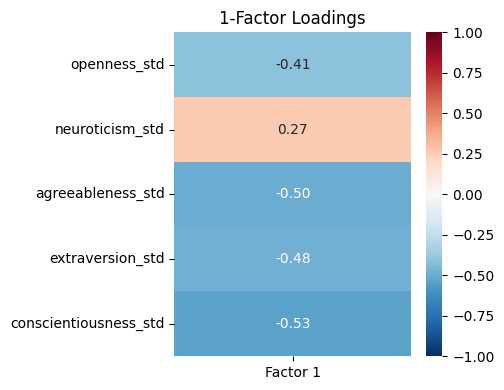

In [25]:
# Heatmap of loadings
plt.figure(figsize=(5, 4))
sns.heatmap(loadings1, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1)
plt.title('1-Factor Loadings')
plt.tight_layout()
plt.show()

2 factor model

In [26]:
n_factors2 = 2
fa2 = FactorAnalyzer(n_factors=n_factors2, rotation='varimax')
fa2.fit(df_fa[traits])

loadings2 = pd.DataFrame(
    fa2.loadings_,
    index=traits,
    columns=['Factor 1', 'Factor 2']
)

communalities2 = pd.DataFrame(
    fa2.get_communalities(),
    index=traits,
    columns=['Communality']
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [27]:
print("\n=== 2-Factor Loadings ===")
print(loadings2.round(3))
print("\n=== Communalities ===")
print(communalities2.round(3))

var2 = fa2.get_factor_variance()
var_df2 = pd.DataFrame(
    var2,
    index=['SS Loadings', 'Proportion Var', 'Cumulative Var'],
    columns=['Factor 1', 'Factor 2']
)
print("\n=== Variance Explained ===")
print(var_df2.round(3))


=== 2-Factor Loadings ===
                       Factor 1  Factor 2
openness_std              0.259     0.285
neuroticism_std          -0.086    -0.281
agreeableness_std         0.723     0.100
extraversion_std          0.152     0.705
conscientiousness_std     0.422     0.250

=== Communalities ===
                       Communality
openness_std                 0.148
neuroticism_std              0.086
agreeableness_std            0.532
extraversion_std             0.520
conscientiousness_std        0.241

=== Variance Explained ===
                Factor 1  Factor 2
SS Loadings        0.798     0.729
Proportion Var     0.160     0.146
Cumulative Var     0.160     0.306


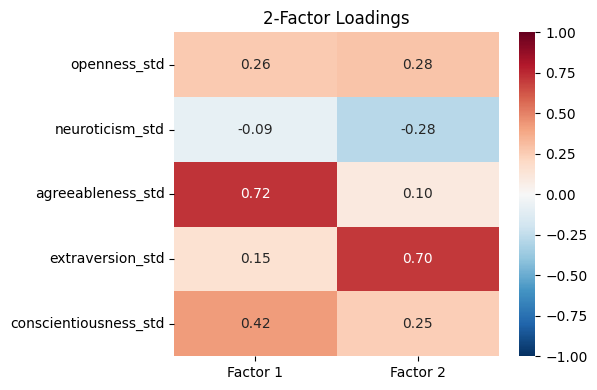

In [28]:
plt.figure(figsize=(6, 4))
sns.heatmap(loadings2, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1)
plt.title('2-Factor Loadings')
plt.tight_layout()
plt.show()

Coding decision tree

In [32]:
features = traits + ['male']
target = 'pomst'

In [33]:
df_tree = df[features + [target]].dropna()

In [34]:
df_tree.head()

,openness_std,neuroticism_std,agreeableness_std,extraversion_std,conscientiousness_std,male,pomst
0,1.134772,1.714700,1.334850,0.318156,-0.471428,1,40.972220
1,-0.410277,1.714700,-0.626826,-0.449034,-0.471428,1,58.333329
2,-1.955325,0.315594,-0.626826,-0.449034,-0.471428,0,78.472226
3,0.362247,-0.383959,1.334850,1.085346,1.368915,0,61.111114
4,1.134772,1.015147,0.354012,1.852535,-0.471428,0,65.972222


decision tree

In [35]:
# Prepare X and y
X = df_tree[features]
y = df_tree[target]

Step 1: Growing Tree

grid search with cross validation

In [36]:
param_grid = {
    "max_depth":         [2, 3, 4, 5, 6],
    "min_samples_leaf":  [30, 50, 75, 100],
    "min_samples_split": [60, 100, 150],
    "ccp_alpha":         [0, 0.01, 0.05, 0.1, 0.5, 1],}

In [37]:
cart = dtr(random_state=17)

grid = GridSearchCV(
    estimator = cart,
    param_grid = param_grid,
    cv = KFold(n_splits=5, shuffle=True, random_state=17),
    scoring = "neg_mean_squared_error",
    n_jobs=-1)

grid.fit(X, y)

GridSearchCV(cv=KFold(n_splits=5, random_state=17, shuffle=True),
             estimator=DecisionTreeRegressor(random_state=17), n_jobs=-1,
             param_grid={'ccp_alpha': [0, 0.01, 0.05, 0.1, 0.5, 1],
                         'max_depth': [2, 3, 4, 5, 6],
                         'min_samples_leaf': [30, 50, 75, 100],
                         'min_samples_split': [60, 100, 150]},
             scoring='neg_mean_squared_error')

In [38]:
print("Best parameters:", grid.best_params_)
print(f"CV MSE (5-fold): {-grid.best_score_:.3f}")

Best parameters: {'ccp_alpha': 0.5, 'max_depth': 4, 'min_samples_leaf': 75, 'min_samples_split': 60}
CV MSE (5-fold): 131.148


In [39]:
tree_model = grid.best_estimator_

[Text(0.5, 0.9, 'neuroticism_std <= -0.034\nsquared_error = 153.228\nsamples = 1047\nvalue = 70.675'),
 Text(0.2, 0.7, 'neuroticism_std <= -0.734\nsquared_error = 99.301\nsamples = 527\nvalue = 74.689'),
 Text(0.35, 0.8, 'True  '),
 Text(0.1, 0.5, 'squared_error = 85.575\nsamples = 274\nvalue = 76.559'),
 Text(0.3, 0.5, 'openness_std <= -0.024\nsquared_error = 106.28\nsamples = 253\nvalue = 72.664'),
 Text(0.2, 0.3, 'squared_error = 108.048\nsamples = 139\nvalue = 71.193'),
 Text(0.4, 0.3, 'squared_error = 98.268\nsamples = 114\nvalue = 74.458'),
 Text(0.8, 0.7, 'neuroticism_std <= 1.365\nsquared_error = 175.012\nsamples = 520\nvalue = 66.608'),
 Text(0.65, 0.8, '  False'),
 Text(0.7, 0.5, 'conscientiousness_std <= -0.011\nsquared_error = 137.79\nsamples = 428\nvalue = 68.202'),
 Text(0.6, 0.3, 'squared_error = 145.279\nsamples = 213\nvalue = 65.897'),
 Text(0.8, 0.3, 'extraversion_std <= -0.065\nsquared_error = 119.899\nsamples = 215\nvalue = 70.484'),
 Text(0.7, 0.1, 'squared_error =

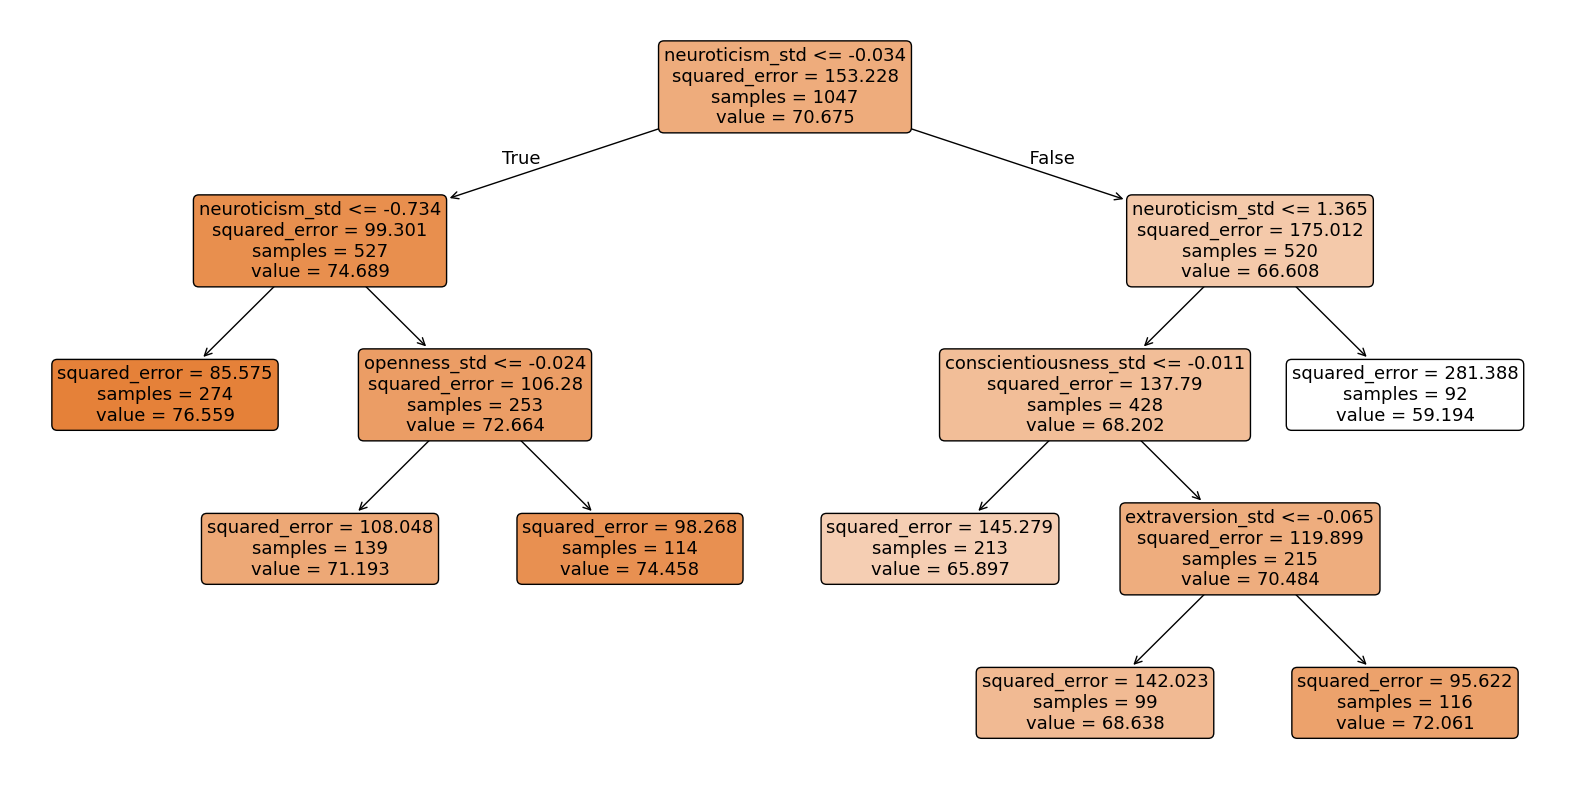

In [40]:
plt.figure(figsize=(20,10))
plot_tree(
    tree_model,
    feature_names=features,
    filled=True,
    rounded=True)

In [41]:
print("Feature Importance:")
for feat, imp in zip(features, tree_model.feature_importances_):
    print(f"  {feat}: {imp:.3f}")

Feature Importance:
  openness_std: 0.023
  neuroticism_std: 0.877
  agreeableness_std: 0.000
  extraversion_std: 0.022
  conscientiousness_std: 0.078
  male: 0.000


Assigning each terminal node to a dummy variable

In [42]:
terminal_indices = tree_model.apply(X)

In [43]:
print(f"# of observations: {len(terminal_indices)}")
print(f"Each unique terminal node: {np.unique(terminal_indices)}")
print(f"# of terminal nodes: {tree_model.get_n_leaves()}")

# of observations: 1047
Each unique terminal node: [ 2  4  5  8 10 11 12]
# of terminal nodes: 7


In [44]:
df['terminal_node'] = terminal_indices

In [45]:
terminal_dummies = pd.get_dummies(df['terminal_node'], prefix='leaf')
df = pd.concat([df, terminal_dummies], axis=1)

In [46]:
df.head()

,pidp,agenew,incomecpi,male,neduc,ueduc,oheduc,Alevel,gcse,otheduc,...,household_size,education,terminal_node,leaf_2,leaf_4,leaf_5,leaf_8,leaf_10,leaf_11,leaf_12
0,68035365,57.041667,2493.496375,1,0,0,0,0,0,1,...,onemember,Other,12,False,False,False,False,False,False,True
1,68058485,64.291667,4008.875375,1,0,0,0,0,1,0,...,twomember,GCSE,12,False,False,False,False,False,False,True
2,68058489,64.291667,4008.875375,0,0,0,0,0,0,1,...,twomember,Other,8,False,False,False,True,False,False,False
3,68064609,57.291667,4231.804125,0,0,0,0,0,1,0,...,twomember,GCSE,5,False,False,True,False,False,False,False
4,68097245,58.791667,1964.208062,0,0,0,0,0,1,0,...,onemember,GCSE,8,False,False,False,True,False,False,False


merging the terminal nodes back to the full df (df_old)

In [47]:
df_old = df_old.merge(df[['pidp', 'terminal_node']], on='pidp', how='left')

relative income measure taking mean (median) of the node and running FE with lincome avdincome and medincome

In [48]:
# Leave-one-out mean income within terminal node

group_sum   = df_old.groupby(["terminal_node", "yearid"])["lincome"].transform("sum")
group_count = df_old.groupby(["terminal_node", "yearid"])["lincome"].transform("count")

df_old["avgincome"] = np.where(
    group_count > 1,
    (group_sum - df_old["lincome"]) / (group_count - 1),
    np.nan)

# Leave-one-out median income within terminal node
def loo_median(series):
    arr = series.to_numpy()
    out = np.full(len(arr), np.nan)
    for i in range(len(arr)):
        others = np.delete(arr, i)
        others = others[~np.isnan(others)]
        if len(others) > 0:
            out[i] = np.median(others)
    return pd.Series(out, index=series.index)

df_old["medincome"] = (
    df_old.groupby(["terminal_node", "yearid"], group_keys=False)["lincome"]
    .apply(loo_median))

purely classifying decision trees seperately by gender

In [49]:
features3 = traits
target = 'pomst'

In [50]:
df_m = df[df['male'] == 1].copy()
df_f = df[df['male'] == 0].copy()

df_tree3 = df_m[['pidp'] + features3 + [target]].dropna().copy()
df_tree4 = df_f[['pidp'] + features3 + [target]].dropna().copy()

print("Males:", len(df_m), "Females:", len(df_f))

Males: 457 Females: 590


In [51]:
print(df['pomst'].var())
print(df_m['pomst'].var())
print(df_f['pomst'].var())

153.37491610946833
138.57811922389
164.82557120505794


In [52]:
# Prepare X and y
X3 = df_tree3[features3]
y3 = df_tree3[target]

X4 = df_tree4[features3]
y4 = df_tree4[target]

male dec tree

In [53]:
param_grid_gender = {
    "max_depth":         [2, 3, 4, 5, 6],
    "min_samples_leaf":  [30, 50, 75, 100],
    "min_samples_split": [60, 100, 150],
    "ccp_alpha":         [0, 0.01, 0.05, 0.1, 0.5, 1],}

In [54]:
grid3 = GridSearchCV(
    estimator=dtr(random_state=17),
    param_grid=param_grid_gender,
    cv=KFold(n_splits=5, shuffle=True, random_state=17),
    scoring="neg_mean_squared_error",
    n_jobs=-1)

grid3.fit(X3, y3)

print("Male best parameters:", grid3.best_params_)
print(f"Male best CV MSE: {-grid3.best_score_:.3f}")

Male best parameters: {'ccp_alpha': 1, 'max_depth': 6, 'min_samples_leaf': 30, 'min_samples_split': 60}
Male best CV MSE: 106.660


In [55]:
tree_model3 = grid3.best_estimator_

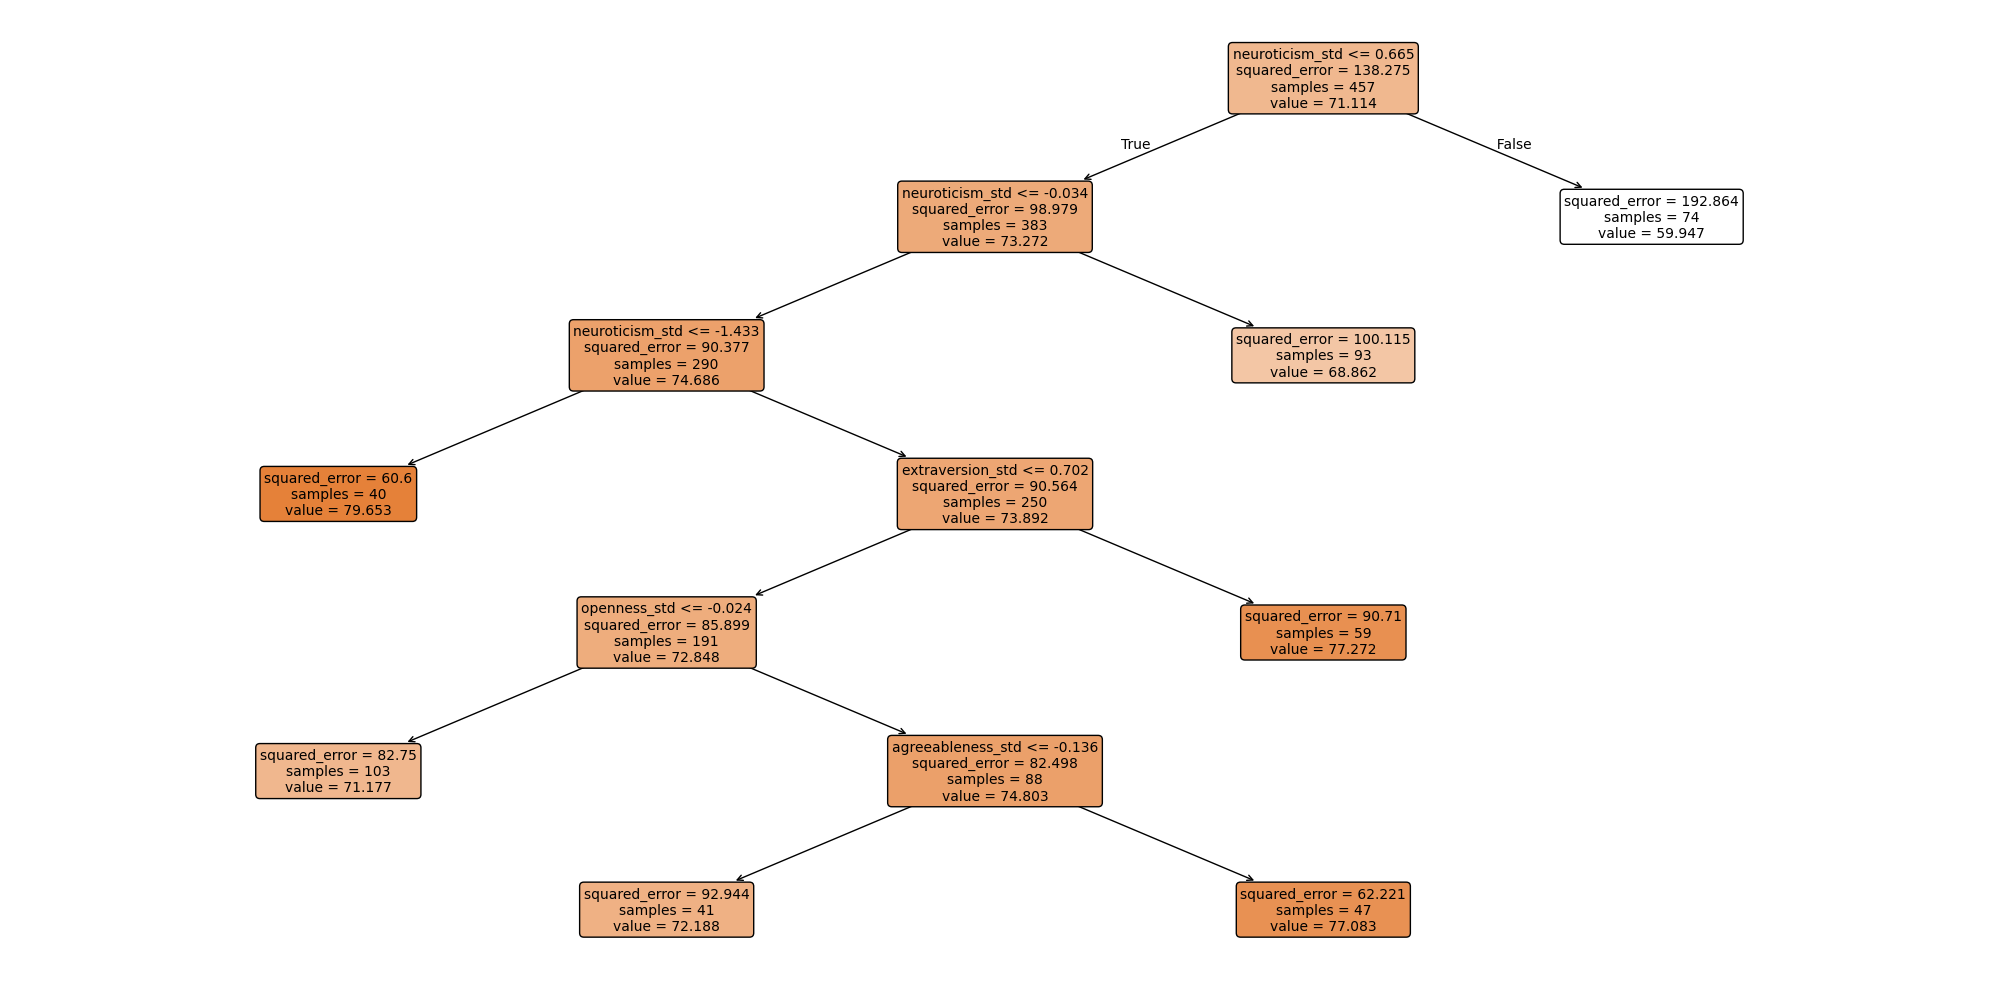

In [56]:
plt.figure(figsize=(20,10))
plot_tree(
    tree_model3,
    feature_names=features3,
    filled=True,
    rounded=True,
    fontsize=10)
plt.tight_layout()

In [57]:
print("Feature Importance:")
for feat, imp in zip(features3, tree_model3.feature_importances_):
    print(f"  {feat}: {imp:.3f}")

Feature Importance:
  openness_std: 0.038
  neuroticism_std: 0.877
  agreeableness_std: 0.032
  extraversion_std: 0.053
  conscientiousness_std: 0.000


In [58]:
print("Male best parameters:", grid3.best_params_)
print(f"Male CV MSE: {-grid3.best_score_:.3f}")
print(f"Leaves: {tree_model3.get_n_leaves()}")
print(f"Depth: {tree_model3.get_depth()}")

Male best parameters: {'ccp_alpha': 1, 'max_depth': 6, 'min_samples_leaf': 30, 'min_samples_split': 60}
Male CV MSE: 106.660
Leaves: 7
Depth: 6


female dec tree

In [59]:
grid4 = GridSearchCV(
    estimator=dtr(random_state=17),
    param_grid=param_grid_gender,
    cv=KFold(n_splits=5, shuffle=True, random_state=17),
    scoring="neg_mean_squared_error",
    n_jobs=-1)

grid4.fit(X4, y4)

print("Female best parameters:", grid4.best_params_)
print(f"Female CV MSE (5-fold): {-grid4.best_score_:.3f}")

Female best parameters: {'ccp_alpha': 0.1, 'max_depth': 5, 'min_samples_leaf': 50, 'min_samples_split': 60}
Female CV MSE (5-fold): 146.036


In [60]:
tree_model4 = grid4.best_estimator_

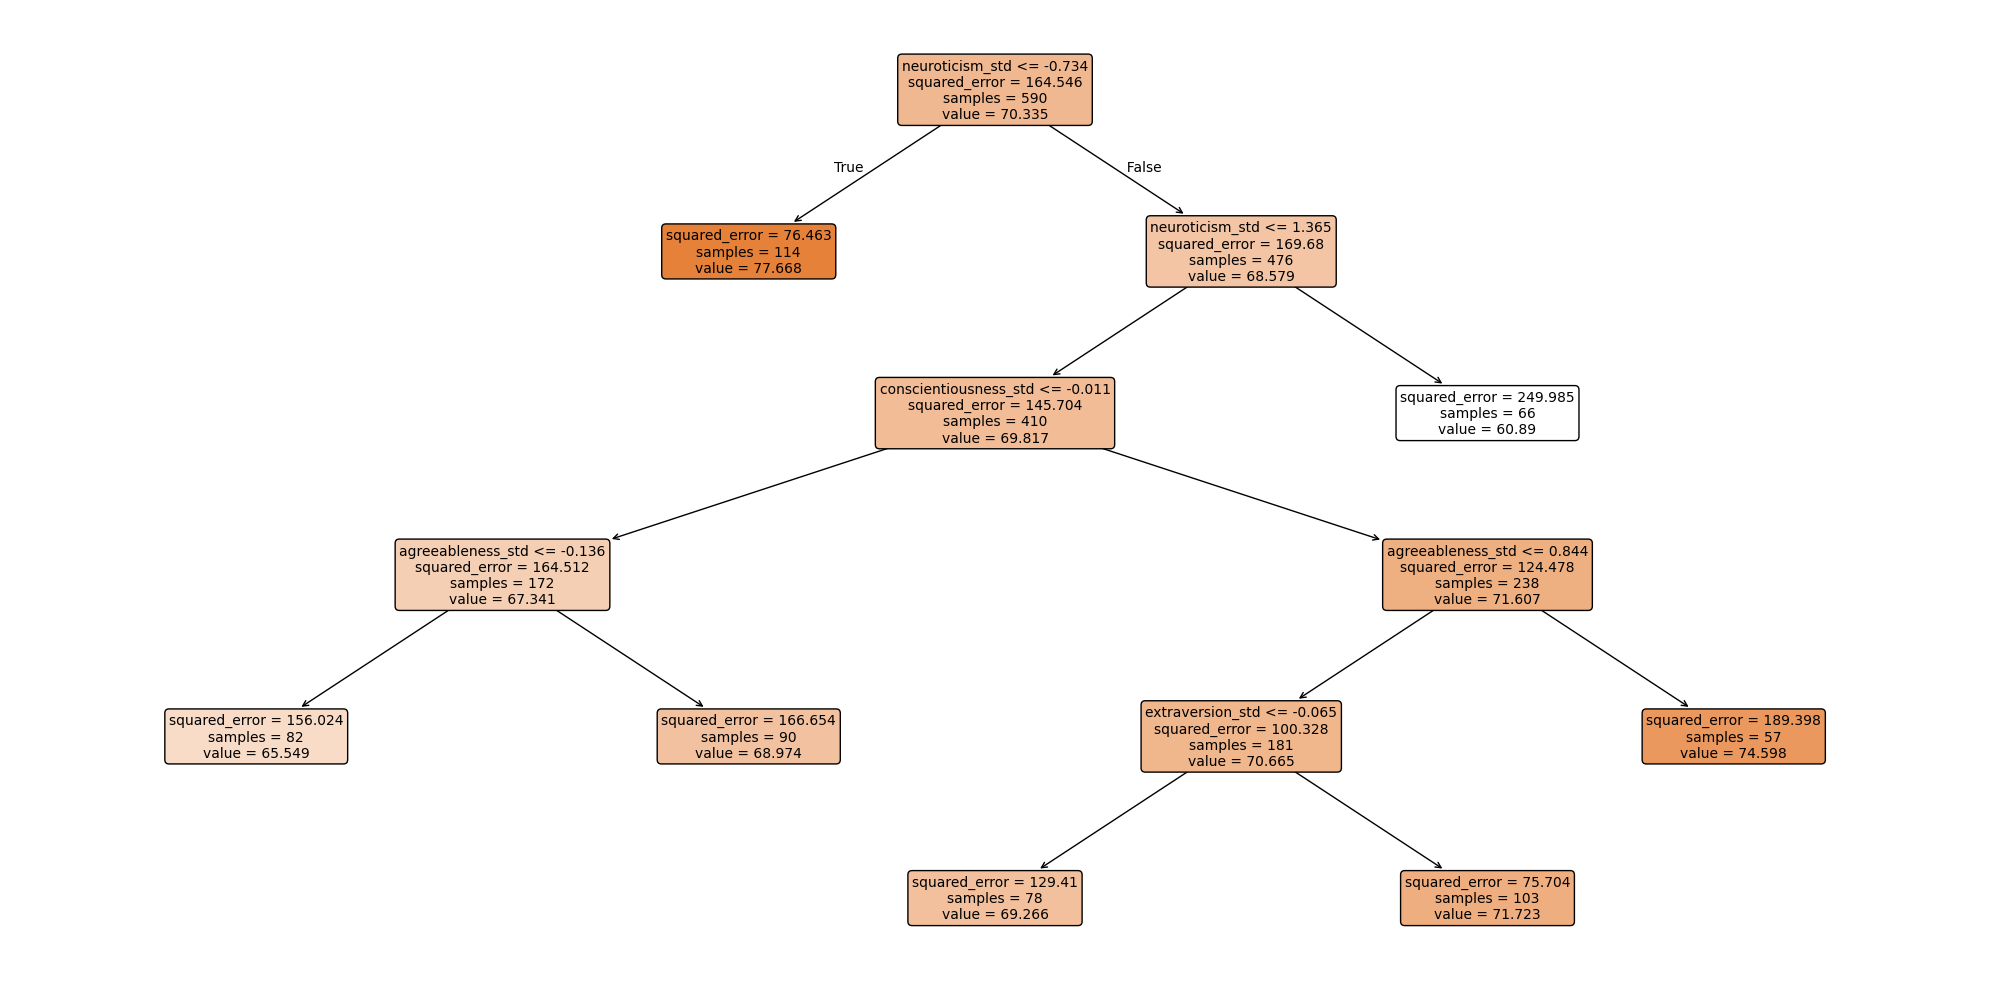

In [61]:
plt.figure(figsize=(20,10))
plot_tree(
    tree_model4,
    feature_names=features3,
    filled=True,
    rounded=True,
    fontsize=10)

plt.tight_layout()

In [62]:
print("Feature Importance:")
for feat, imp in zip(features3, tree_model4.feature_importances_):
    print(f"  {feat}: {imp:.3f}")

Feature Importance:
  openness_std: 0.000
  neuroticism_std: 0.788
  agreeableness_std: 0.076
  extraversion_std: 0.017
  conscientiousness_std: 0.118


assigning each node to a dummy variable (male)

In [63]:
terminal_indices1 = tree_model3.apply(X3)

print(f"# of observations: {len(terminal_indices1)}")
print(f"Each unique terminal node: {np.unique(terminal_indices1)}")
print(f"# of terminal nodes: {tree_model3.get_n_leaves()}")

# of observations: 457
Each unique terminal node: [ 3  6  8  9 10 11 12]
# of terminal nodes: 7


In [64]:
df_tree3['terminal_node_m'] = terminal_indices1

terminal_dummies1 = pd.get_dummies(df_tree3['terminal_node_m'], prefix='leaf')
df_tree3 = pd.concat([df_tree3, terminal_dummies1], axis=1)

In [65]:
df_tree3.head()

,pidp,openness_std,neuroticism_std,agreeableness_std,extraversion_std,conscientiousness_std,pomst,terminal_node_m,leaf_3,leaf_6,leaf_8,leaf_9,leaf_10,leaf_11,leaf_12
0,68035365,1.134772,1.714700,1.334850,0.318156,-0.471428,40.972220,12,False,False,False,False,False,False,True
1,68058485,-0.410277,1.714700,-0.626826,-0.449034,-0.471428,58.333329,12,False,False,False,False,False,False,True
7,68138045,1.134772,-0.383959,0.354012,1.852535,0.448744,81.250004,10,False,False,False,False,True,False,False
10,68297845,1.134772,-1.083512,0.354012,1.085346,0.448744,84.027781,10,False,False,False,False,True,False,False
13,68320965,-0.410277,-1.083512,-0.626826,-0.449034,-0.471428,72.222223,6,False,True,False,False,False,False,False


merging the terminal nodes back to the full df (df_old)

In [66]:
df_old_m = df_old[df_old['male'] == 1].copy()
df_old_f = df_old[df_old['male'] == 0].copy()

In [67]:
df_old_m = df_old_m.merge(df_tree3[['pidp', 'terminal_node_m']], on='pidp', how='left')

# Recomputing LOO relative income within male leaves

group_sum_m   = df_old_m.groupby(["terminal_node_m", "yearid"])["lincome"].transform("sum")
group_count_m = df_old_m.groupby(["terminal_node_m", "yearid"])["lincome"].transform("count")
df_old_m["avgincome"] = np.where(
    group_count_m > 1,
    (group_sum_m - df_old_m["lincome"]) / (group_count_m - 1),
    np.nan)
df_old_m["medincome"] = (
    df_old_m.groupby(["terminal_node_m", "yearid"], group_keys=False)["lincome"]
    .apply(loo_median))

assigning each node to a dummy variable (female)

In [68]:
terminal_indices2 = tree_model4.apply(X4)

print(f"# of observations: {len(terminal_indices2)}")
print(f"Each unique terminal node: {np.unique(terminal_indices2)}")
print(f"# of terminal nodes: {tree_model4.get_n_leaves()}")

df_tree4['terminal_node_f'] = terminal_indices2

terminal_dummies2 = pd.get_dummies(df_tree4['terminal_node_f'], prefix='leaf')
df_tree4 = pd.concat([df_tree4, terminal_dummies2], axis=1)

df_tree4.head()

# of observations: 590
Each unique terminal node: [ 1  5  6  9 10 11 12]
# of terminal nodes: 7


,pidp,openness_std,neuroticism_std,agreeableness_std,extraversion_std,conscientiousness_std,pomst,terminal_node_f,leaf_1,leaf_5,leaf_6,leaf_9,leaf_10,leaf_11,leaf_12
2,68058489,-1.955325,0.315594,-0.626826,-0.449034,-0.471428,78.472226,5,False,True,False,False,False,False,False
3,68064609,0.362247,-0.383959,1.334850,1.085346,1.368915,61.111114,11,False,False,False,False,False,True,False
4,68097245,1.134772,1.015147,0.354012,1.852535,-0.471428,65.972222,6,False,False,True,False,False,False,False
5,68133285,0.362247,1.015147,0.354012,0.318156,-0.471428,68.055555,6,False,False,True,False,False,False,False
6,68137365,-1.955325,-0.383959,1.334850,1.085346,1.368915,70.138888,11,False,False,False,False,False,True,False


merging the terminal nodes back to the full df (df_old)

In [69]:
df_old_f = df_old_f.merge(df_tree4[['pidp', 'terminal_node_f']], on='pidp', how='left')

# Recomputing LOO relative income within female leaves

group_sum_f   = df_old_f.groupby(["terminal_node_f", "yearid"])["lincome"].transform("sum")
group_count_f = df_old_f.groupby(["terminal_node_f", "yearid"])["lincome"].transform("count")
df_old_f["avgincome"] = np.where(
    group_count_f > 1,
    (group_sum_f - df_old_f["lincome"]) / (group_count_f - 1),
    np.nan)
df_old_f["medincome"] = (
    df_old_f.groupby(["terminal_node_f", "yearid"], group_keys=False)["lincome"]
    .apply(loo_median))

summary stats

In [70]:
desc = df_old.groupby("terminal_node").agg(
    n_individuals=("pidp", "nunique"),
    n_observations=("pomst", "count"),
    mean_ls=("pomst", "mean"),
    mean_lincome=("lincome", "mean"),
    male_share=("male", "mean")
).round(3)
print(desc)

               n_individuals  n_observations  mean_ls  mean_lincome  \
terminal_node                                                         
2                        274            6576   76.559         8.119   
4                        139            3336   71.193         8.042   
5                        114            2736   74.458         8.222   
8                        213            5112   65.897         8.067   
10                        99            2376   68.638         8.190   
11                       116            2784   72.061         8.052   
12                        92            2208   59.194         7.979   

               male_share  
terminal_node              
2                   0.584  
4                   0.525  
5                   0.500  
8                   0.401  
10                  0.293  
11                  0.224  
12                  0.283  


First setting up variables/configuration for function

In [71]:
Model_FE = ["No FE", "pidp FE", "pidp+year FE"]

Controls = {
    "None":        [],
    "Age_c":       ["agenew", "agesq"],
    "Household_c": ["agenew", "agesq", "onemember", "member34", "othersize"],
    "Education_c": ["agenew", "agesq", "neduc", "ueduc", "oheduc", "Alevel", "otheduc"],
    "All_c":       ["agenew", "agesq", "onemember", "member34", "othersize",
                    "neduc", "ueduc", "oheduc", "Alevel", "otheduc"],

    # robustness only — bad control

    "Robustness_c": ["agenew", "agesq", "onemember", "member34", "othersize",
                     "neduc", "ueduc", "oheduc", "Alevel", "otheduc",
                     "single", "others",
                     "selfemploy", "unemploy", "retired", "sick", "familycare", "student"],}

panel_cols = {"pomst", "pidp", "yearid"}

Income_c = {
    "lincome_only": {
        "required":            ["pomst", "lincome", "pidp", "yearid"],
        "relative_income_var": None,
        "plot_var":            "lincome",
    },
    "lincome_avgincome": {
        "required":            ["pomst", "lincome", "avgincome", "pidp", "yearid"],
        "relative_income_var": "avgincome",
        "plot_var":            "avgincome",
    },
    "lincome_medincome": {
        "required":            ["pomst", "lincome", "medincome", "pidp", "yearid"],
        "relative_income_var": "medincome",
        "plot_var":            "medincome",
    },
    "lincome_quad": {
        "required":            ["pomst", "lincome", "lincome_sq", "pidp", "yearid"],
        "relative_income_var": None,
        "plot_var":            "lincome",
    },
    "lincome_quad_avgincome": {
        "required":            ["pomst", "lincome", "lincome_sq", "avgincome", "pidp", "yearid"],
        "relative_income_var": "avgincome",
        "plot_var":            "avgincome",
    },
    "lincome_quad_medincome": {
        "required":            ["pomst", "lincome", "lincome_sq", "medincome", "pidp", "yearid"],
        "relative_income_var": "medincome",
        "plot_var":            "medincome",
    },}

In [72]:
def IncLifeSat_model(df_sample, node_id, label=""):

    results = []
    models  = {}

    for leaf in sorted(df_sample[node_id].dropna().unique()):
        leaf = int(leaf)
        sub  = df_sample[df_sample[node_id] == leaf].copy()

        for ctrl_name, ctrl_vars in Controls.items():
            for spec_name in Model_FE:
                for income_type, spec in Income_c.items():

                    needed    = list(dict.fromkeys(spec["required"] + ctrl_vars))
                    sub_clean = sub[needed].dropna()

                    if sub_clean.empty or sub_clean["pidp"].nunique() < 2:
                        continue

                    try:
                        sub_panel = sub_clean.set_index(["pidp", "yearid"])
                    except KeyError:
                        continue

                    exog_vars = [v for v in spec["required"] if v not in panel_cols] + ctrl_vars
                    exog      = sm.add_constant(sub_panel[exog_vars], has_constant='add')

                    try:
                        if spec_name == "No FE":
                            model = PooledOLS(sub_panel["pomst"], exog).fit(
                                cov_type="clustered", cluster_entity=True)
                        elif spec_name == "pidp FE":
                            model = PanelOLS(
                                sub_panel["pomst"], exog,
                                entity_effects=True, time_effects=False
                            ).fit(cov_type="clustered", cluster_entity=True)
                        elif spec_name == "pidp+year FE":
                            model = PanelOLS(
                                sub_panel["pomst"], exog,
                                entity_effects=True, time_effects=True
                            ).fit(cov_type="clustered", cluster_entity=True)
                        else:
                            continue
                    except Exception:
                        continue

                    models[(label, leaf, income_type, ctrl_name, spec_name)] = model
                    rel_var = spec["relative_income_var"]

                    # quadratic peak in log income

                    b1 = model.params.get("lincome",    np.nan)
                    b2 = model.params.get("lincome_sq", np.nan)
                    if pd.notna(b1) and pd.notna(b2) and b2 != 0:
                        peak_log    = -b1 / (2 * b2)
                        peak_pounds = float(np.exp(peak_log))
                    else:
                        peak_log = np.nan
                        peak_pounds = np.nan

                    try:
                        f_stat = float(model.f_statistic.stat)
                        f_pval = float(model.f_statistic.pval)
                    except Exception:
                        f_stat = np.nan
                        f_pval = np.nan

                    results.append({
                        "sample":          label,
                        "leaf":            leaf,
                        "income_type":     income_type,
                        "controls":        ctrl_name,
                        "fe_spec":         spec_name,

                        "coef_lincome":    model.params.get("lincome",    np.nan),
                        "pval_lincome":    model.pvalues.get("lincome",   np.nan),
                        "coef_lincome_sq": model.params.get("lincome_sq", np.nan),
                        "pval_lincome_sq": model.pvalues.get("lincome_sq", np.nan),

                        "coef_rel_income": model.params.get(rel_var, np.nan) if rel_var else np.nan,
                        "pval_rel_income": model.pvalues.get(rel_var, np.nan) if rel_var else np.nan,

                        "se_lincome":      model.std_errors.get("lincome",    np.nan),
                        "se_lincome_sq":   model.std_errors.get("lincome_sq", np.nan),
                        "se_rel_income":   model.std_errors.get(rel_var, np.nan) if rel_var else np.nan,

                        "observations_no": int(model.nobs),
                        "n_individuals":   int(sub_clean["pidp"].nunique()),
                        "rsquared":        float(getattr(model, "rsquared", np.nan)),
                        "rsquared_within": float(getattr(model, "rsquared_within", np.nan)),
                        "f_statistic":     f_stat,
                        "f_pvalue":        f_pval,
                        "peak_log_income": peak_log,
                        "peak_income_gbp": peak_pounds,
                    })

    return pd.DataFrame(results), models

In [73]:
results_all,    models_all    = IncLifeSat_model(df_old,   "terminal_node",   label="All")
results_male,   models_male   = IncLifeSat_model(df_old_m, "terminal_node_m", label="Male")
results_female, models_female = IncLifeSat_model(df_old_f, "terminal_node_f", label="Female")

results_df = pd.concat([results_all, results_male, results_female], ignore_index=True)
all_models = {**models_all, **models_male, **models_female}

print(results_df.to_string())

/tmp/ipykernel_1378/12277089.py:56: RuntimeWarning: overflow encountered in exp
  peak_pounds = float(np.exp(peak_log))
/tmp/ipykernel_1378/12277089.py:56: RuntimeWarning: overflow encountered in exp
  peak_pounds = float(np.exp(peak_log))


      sample  leaf             income_type      controls       fe_spec  coef_lincome  pval_lincome  coef_lincome_sq  pval_lincome_sq  coef_rel_income  pval_rel_income  se_lincome  se_lincome_sq  se_rel_income  observations_no  n_individuals      rsquared  rsquared_within  f_statistic      f_pvalue  peak_log_income  peak_income_gbp
0        All     2            lincome_only          None         No FE      0.117605  8.472988e-01              NaN              NaN              NaN              NaN    0.610703            NaN            NaN             6576            274  2.028531e-05     1.173390e-05     0.133358  7.149869e-01              NaN              NaN
1        All     2       lincome_avgincome          None         No FE      0.139869  8.204675e-01              NaN              NaN        -1.937849         0.566348    0.616289            NaN       3.379180             6576            274  1.027763e-04     1.198048e-04     0.337809  7.133439e-01              NaN              NaN
2

In [74]:
# Per-leaf descriptive statistics for thesis tables

def leaf_descriptives(df_panel, node_col, label):
    agg = (df_panel.dropna(subset=[node_col])
                   .groupby(node_col)
                   .agg(
                        n_obs          = ("pomst",     "size"),
                        n_indiv        = ("pidp",      "nunique"),
                        pomst_mean     = ("pomst",     "mean"),
                        pomst_sd       = ("pomst",     "std"),
                        lincome_mean   = ("lincome",   "mean"),
                        lincome_sd     = ("lincome",   "std"),
                        avgincome_mean = ("avgincome", "mean"),
                        medincome_mean = ("medincome", "mean"),
                        age_mean       = ("agenew",    "mean"),
                   )
                   .round(3)
                   .reset_index()
                   .rename(columns={node_col: "leaf"}))
    agg.insert(0, "sample", label)
    return agg

desc_all = leaf_descriptives(df_old, "terminal_node", "All")

# gender share for all sample

male_share = (df_old.dropna(subset=["terminal_node"])
                    .groupby("terminal_node")["male"]
                    .mean()
                    .round(3)
                    .reset_index()
                    .rename(columns={"terminal_node": "leaf", "male": "male_share"}))
desc_all = desc_all.merge(male_share, on="leaf", how="left")

desc_male   = leaf_descriptives(df_old_m, "terminal_node_m", "Male")
desc_female = leaf_descriptives(df_old_f, "terminal_node_f", "Female")

leaf_descriptives_all = pd.concat(
    [desc_all, desc_male, desc_female], ignore_index=True, sort=False)

print(leaf_descriptives_all)
leaf_descriptives_all.to_csv("leaf_descriptives.csv", index=False)

    sample  leaf  n_obs  n_indiv  pomst_mean  pomst_sd  lincome_mean  \
0      All   2.0   6576      274      76.559    19.137         8.119   
1      All   4.0   3336      139      71.193    19.953         8.042   
2      All   5.0   2736      114      74.458    18.900         8.222   
3      All   8.0   5112      213      65.897    20.775         8.067   
4      All  10.0   2376       99      68.638    21.197         8.190   
5      All  11.0   2784      116      72.061    19.371         8.052   
6      All  12.0   2208       92      59.194    24.436         7.979   
7     Male   3.0    960       40      79.653    17.746         8.143   
8     Male   6.0   2472      103      71.177    18.847         8.149   
9     Male   8.0    984       41      72.188    18.583         8.225   
10    Male   9.0   1128       47      77.083    16.765         8.224   
11    Male  10.0   1416       59      77.272    18.406         8.169   
12    Male  11.0   2220       93      68.889    19.669         8

In [75]:
# Mapping each terminal node to the decision path that produced it

def leaf_path_mapping(tree, feature_names, label=""):
    tree_ = tree.tree_
    paths = {}

    def recurse(node_id, conditions):
        if tree_.feature[node_id] == -2:   # -2 marks a leaf
            paths[node_id] = " & ".join(conditions) if conditions else "(root)"
            return
        feat   = feature_names[tree_.feature[node_id]]
        thresh = tree_.threshold[node_id]
        recurse(tree_.children_left[node_id],
                conditions + [f"{feat} <= {thresh:.3f}"])
        recurse(tree_.children_right[node_id],
                conditions + [f"{feat} > {thresh:.3f}"])

    recurse(0, [])
    return pd.DataFrame(
        [{"sample": label, "leaf": k, "path": v} for k, v in sorted(paths.items())])

mapping_all    = leaf_path_mapping(tree_model,  features,  label="All")
mapping_male   = leaf_path_mapping(tree_model3, features3, label="Male")
mapping_female = leaf_path_mapping(tree_model4, features3, label="Female")

leaf_path_table = pd.concat(
    [mapping_all, mapping_male, mapping_female], ignore_index=True)

print(leaf_path_table.to_string(index=False))
leaf_path_table.to_csv("leaf_paths.csv", index=False)

sample  leaf                                                                                                                                                              path
   All     2                                                                                                             neuroticism_std <= -0.034 & neuroticism_std <= -0.734
   All     4                                                                                     neuroticism_std <= -0.034 & neuroticism_std > -0.734 & openness_std <= -0.024
   All     5                                                                                      neuroticism_std <= -0.034 & neuroticism_std > -0.734 & openness_std > -0.024
   All     8                                                                             neuroticism_std > -0.034 & neuroticism_std <= 1.365 & conscientiousness_std <= -0.011
   All    10                                                 neuroticism_std > -0.034 & neuroticism_std <= 1.365 & conscienti

In [76]:
from google.colab import files
files.download("leaf_descriptives.csv")
files.download("leaf_paths.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

checking numbers

In [77]:
print("All leaves:",    df_old['terminal_node'].dropna().nunique())
print("Male leaves:",   df_old_m['terminal_node_m'].dropna().nunique())
print("Female leaves:", df_old_f['terminal_node_f'].dropna().nunique())

All leaves: 7
Male leaves: 7
Female leaves: 7


In [78]:
print(f"Total models stored: {len(all_models)}")

Total models stored: 1902


test statistics for results_df

In [79]:
# Basic summary statistics for all numeric columns
print(results_df.describe())

              leaf  coef_lincome  pval_lincome  coef_lincome_sq  \
count  1902.000000   1902.000000  1.902000e+03       951.000000   
mean      7.895899     -0.488263  4.402044e-01         0.169838   
std       3.426341      5.535946  3.109611e-01         0.384069   
min       1.000000    -69.248908  2.294182e-09        -0.859455   
25%       5.000000     -1.432091  1.600145e-01        -0.074739   
50%       9.000000      0.210589  4.236092e-01         0.103040   
75%      11.000000      1.702347  7.220799e-01         0.368181   
max      12.000000     15.286169  9.988618e-01         1.579215   

       pval_lincome_sq  coef_rel_income  pval_rel_income   se_lincome  \
count       951.000000      1196.000000      1196.000000  1902.000000   
mean          0.456990       -50.045782         0.484702     3.517720   
std           0.320402       464.254675         0.289047    12.742201   
min           0.000007     -6343.433027         0.000130     0.570806   
25%           0.148915        -

In [80]:
# Value counts for categorical columns
print("\nSamples:")
print(results_df["sample"].value_counts())

print("\nIncome types:")
print(results_df["income_type"].value_counts())

print("\nControls:")
print(results_df["controls"].value_counts())

print("\nFE specs:")
print(results_df["fe_spec"].value_counts())


Samples:
sample
All       672
Female    672
Male      558
Name: count, dtype: int64

Income types:
income_type
lincome_only              353
lincome_medincome         353
lincome_quad_medincome    353
lincome_quad              353
lincome_avgincome         245
lincome_quad_avgincome    245
Name: count, dtype: int64

Controls:
controls
None            338
Age_c           338
Household_c     338
Education_c     298
All_c           298
Robustness_c    292
Name: count, dtype: int64

FE specs:
fe_spec
No FE           750
pidp FE         684
pidp+year FE    468
Name: count, dtype: int64


latex

In [81]:
if not hasattr(pd.DataFrame, 'append'):
    pd.DataFrame.append = lambda self, other, **kwargs: pd.concat(
        [self, pd.DataFrame([other]) if isinstance(other, dict) else other],
        ignore_index=kwargs.get('ignore_index', False)
    )

In [82]:
ctrl_label_map = {
    "None": "No",
    "Age_c": "Age",
    "Household_c": "Household",
    "Education_c": "Education",
    "All_c": "All"
}

income_label_map = {
    "lincome_only": "own income",
    "lincome_avgincome": "own income and average relative income",
    "lincome_medincome": "own income and median relative income",
    "lincome_quad": "own income (quadratic)",
    "lincome_quad_avgincome": "own income (quadratic) and average relative income",
    "lincome_quad_medincome": "own income (quadratic) and median relative income",
}

fe_label_map = {
    "No FE": "No FE",
    "pidp FE": "PIDP FE",
    "pidp+year FE": "PIDP + year FE",
}

In [83]:
def make_panel_tabular(results_df, income_type, sample, controls, fe_specs_list, filename):
    """
    Builds a LaTeX TABULAR ONLY.
    Leaf numbers are bolded if any coefficient is significant at 5%.
    """

    lines = []

    spec     = Income_c[income_type]
    rel_var  = spec["relative_income_var"]
    has_quad = "lincome_sq" in spec["required"]
    has_rel  = rel_var is not None

    n_fe = len(fe_specs_list)

    if has_quad and has_rel:
        vars_per_fe = 3
        var_labels  = [r"lincome", r"lincome$^2$", rel_var]
    elif has_quad:
        vars_per_fe = 2
        var_labels  = [r"lincome", r"lincome$^2$"]
    elif has_rel:
        vars_per_fe = 2
        var_labels  = [r"lincome", rel_var]
    else:
        vars_per_fe = 1
        var_labels  = [r"lincome"]

    total_cols = 1 + vars_per_fe * n_fe
    col_format = "c" * total_cols

    lines.append(rf"\begin{{tabular}}{{{col_format}}}")
    lines.append(r"\hline\hline")

    fe_header = r"Leaf"
    for fe_name in fe_specs_list:
        fe_header += rf" & \multicolumn{{{vars_per_fe}}}{{c}}{{{fe_label_map.get(fe_name, fe_name)}}}"
    lines.append(fe_header + r" \\")

    var_header = ""
    for _ in fe_specs_list:
        for v in var_labels:
            var_header += f" & {v}"
    lines.append(var_header + r" \\")
    lines.append(r"\hline")

    def fmt_coef(coef, se, pval):
        if pd.isna(coef):
            return "—", ""
        stars = ""
        if pval < 0.01:
            stars = "^{***}"
        elif pval < 0.05:
            stars = "^{**}"
        elif pval < 0.10:
            stars = "^{*}"
        coef_str = f"${coef:.3f}{stars}$"
        se_str   = f"$({se:.3f})$" if not pd.isna(se) else ""
        return coef_str, se_str

    def row_is_significant(r):
        """Returns True if any coefficient is significant at 5%."""
        pvals = [
            r["pval_lincome"],
            r["pval_lincome_sq"],
            r["pval_rel_income"],
        ]
        return any(pd.notna(p) and p < 0.05 for p in pvals)

    leaves = sorted(results_df[
        (results_df["sample"] == sample) &
        (results_df["income_type"] == income_type) &
        (results_df["controls"] == controls) &
        (results_df["fe_spec"] == fe_specs_list[0])
    ]["leaf"].dropna().unique())

    for leaf in leaves:

        # Check significance across all FE specs for this leaf
        all_rows = results_df[
            (results_df["sample"] == sample) &
            (results_df["income_type"] == income_type) &
            (results_df["controls"] == controls) &
            (results_df["leaf"] == leaf) &
            (results_df["fe_spec"].isin(fe_specs_list))
        ]
        any_sig = any(row_is_significant(r) for _, r in all_rows.iterrows())

        leaf_label = rf"\textbf{{{int(leaf)}}}" if any_sig else f"{int(leaf)}"
        coef_row = leaf_label
        se_row   = ""

        for fe_name in fe_specs_list:
            row = results_df[
                (results_df["sample"] == sample) &
                (results_df["income_type"] == income_type) &
                (results_df["controls"] == controls) &
                (results_df["fe_spec"] == fe_name) &
                (results_df["leaf"] == leaf)
            ]

            if row.empty:
                coef_row += " & —" * vars_per_fe
                se_row   += " & " * vars_per_fe
                continue

            r = row.iloc[0]

            if has_quad and has_rel:
                c1, s1 = fmt_coef(r["coef_lincome"],    r["se_lincome"],    r["pval_lincome"])
                c2, s2 = fmt_coef(r["coef_lincome_sq"], r["se_lincome_sq"], r["pval_lincome_sq"])
                c3, s3 = fmt_coef(r["coef_rel_income"], r["se_rel_income"], r["pval_rel_income"])
                coef_row += f" & {c1} & {c2} & {c3}"
                se_row   += f" & {s1} & {s2} & {s3}"
            elif has_quad:
                c1, s1 = fmt_coef(r["coef_lincome"],    r["se_lincome"],    r["pval_lincome"])
                c2, s2 = fmt_coef(r["coef_lincome_sq"], r["se_lincome_sq"], r["pval_lincome_sq"])
                coef_row += f" & {c1} & {c2}"
                se_row   += f" & {s1} & {s2}"
            elif has_rel:
                c1, s1 = fmt_coef(r["coef_lincome"],    r["se_lincome"],    r["pval_lincome"])
                c3, s3 = fmt_coef(r["coef_rel_income"], r["se_rel_income"], r["pval_rel_income"])
                coef_row += f" & {c1} & {c3}"
                se_row   += f" & {s1} & {s3}"
            else:
                c1, s1 = fmt_coef(r["coef_lincome"], r["se_lincome"], r["pval_lincome"])
                coef_row += f" & {c1}"
                se_row   += f" & {s1}"

        lines.append(coef_row + r" \\")
        lines.append(se_row + r" \\")

    lines.append(r"\hline\hline")
    lines.append(
        rf"\multicolumn{{{total_cols}}}{{c}}{{\footnotesize "
        rf"$^{{***}}p<0.01$, $^{{**}}p<0.05$, $^*p<0.10$. "
        rf"Controls: {ctrl_label_map.get(controls, controls)}.}} \\"
    )
    lines.append(r"\end{tabular}")

    latex = "\n".join(lines)
    with open(filename, "w") as f:
        f.write(latex)

    print(f"Saved: {filename}")
    return latex

In [84]:
# Generating Tabular latex files

ctrl_sets = ["None", "Age_c", "Household_c", "Education_c", "All_c"]

# Own income specs - full three FE columns
for income_type, prefix in [
    ("lincome_only",          "Lin"),
    ("lincome_quad",          "A"),
]:
    fe_specs = ["No FE", "pidp FE", "pidp+year FE"]
    for sample in ["All", "Male", "Female"]:
        for ctrl in ctrl_sets:
            fname = f"tabular_{prefix}_{sample.lower()}_{ctrl}.tex"
            make_panel_tabular(results_df, income_type=income_type,
                               sample=sample, controls=ctrl,
                               fe_specs_list=fe_specs, filename=fname)

# All relative income specs - pidp + year FE excluded
for income_type, prefix in [
    ("lincome_avgincome",      "LinAvg"),
    ("lincome_medincome",      "LinMed"),
    ("lincome_quad_avgincome", "B"),
    ("lincome_quad_medincome", "C"),
]:
    fe_specs_rel = ["No FE", "pidp FE"]
    for sample in ["All", "Male", "Female"]:
        for ctrl in ctrl_sets:
            fname = f"tabular_{prefix}_{sample.lower()}_{ctrl}.tex"
            make_panel_tabular(results_df, income_type=income_type,
                               sample=sample, controls=ctrl,
                               fe_specs_list=fe_specs_rel, filename=fname)

Saved: tabular_Lin_all_None.tex
Saved: tabular_Lin_all_Age_c.tex
Saved: tabular_Lin_all_Household_c.tex
Saved: tabular_Lin_all_Education_c.tex
Saved: tabular_Lin_all_All_c.tex
Saved: tabular_Lin_male_None.tex
Saved: tabular_Lin_male_Age_c.tex
Saved: tabular_Lin_male_Household_c.tex
Saved: tabular_Lin_male_Education_c.tex
Saved: tabular_Lin_male_All_c.tex
Saved: tabular_Lin_female_None.tex
Saved: tabular_Lin_female_Age_c.tex
Saved: tabular_Lin_female_Household_c.tex
Saved: tabular_Lin_female_Education_c.tex
Saved: tabular_Lin_female_All_c.tex
Saved: tabular_A_all_None.tex
Saved: tabular_A_all_Age_c.tex
Saved: tabular_A_all_Household_c.tex
Saved: tabular_A_all_Education_c.tex
Saved: tabular_A_all_All_c.tex
Saved: tabular_A_male_None.tex
Saved: tabular_A_male_Age_c.tex
Saved: tabular_A_male_Household_c.tex
Saved: tabular_A_male_Education_c.tex
Saved: tabular_A_male_All_c.tex
Saved: tabular_A_female_None.tex
Saved: tabular_A_female_Age_c.tex
Saved: tabular_A_female_Household_c.tex
Saved: t

In [85]:
from google.colab import files
import glob
import zipfile

In [86]:
print(glob.glob("tabular_*.tex"))

['tabular_LinAvg_male_Education_c.tex', 'tabular_Lin_male_Age_c.tex', 'tabular_A_all_All_c.tex', 'tabular_B_female_None.tex', 'tabular_A_male_All_c.tex', 'tabular_B_female_Education_c.tex', 'tabular_LinAvg_female_Age_c.tex', 'tabular_LinAvg_all_Household_c.tex', 'tabular_C_female_Education_c.tex', 'tabular_LinAvg_male_Age_c.tex', 'tabular_Lin_male_All_c.tex', 'tabular_C_male_Education_c.tex', 'tabular_B_all_None.tex', 'tabular_A_male_Education_c.tex', 'tabular_LinAvg_all_Age_c.tex', 'tabular_A_female_Education_c.tex', 'tabular_LinMed_female_None.tex', 'tabular_A_male_Age_c.tex', 'tabular_A_all_Household_c.tex', 'tabular_LinAvg_all_All_c.tex', 'tabular_C_all_Age_c.tex', 'tabular_B_male_None.tex', 'tabular_Lin_female_Age_c.tex', 'tabular_Lin_male_Education_c.tex', 'tabular_LinAvg_all_None.tex', 'tabular_A_all_Age_c.tex', 'tabular_B_female_Age_c.tex', 'tabular_Lin_all_Age_c.tex', 'tabular_LinAvg_female_Education_c.tex', 'tabular_LinAvg_male_Household_c.tex', 'tabular_LinAvg_female_None.te

In [87]:
matches = sorted(glob.glob("tabular_*.tex"))
print("Matched files:", matches)
print("Current working directory:", os.getcwd())

if not matches:
    print("No tabular_*.tex files found.")
else:
    with zipfile.ZipFile("regression_tables.zip", "w") as zf:
        for f in matches:
                zf.write(f)
                print(f"Added: {f}")

    print("Created zip:", os.path.exists("regression_tables.zip"), os.path.getsize("regression_tables.zip"))
    files.download("regression_tables.zip")

Matched files: ['tabular_A_all_Age_c.tex', 'tabular_A_all_All_c.tex', 'tabular_A_all_Education_c.tex', 'tabular_A_all_Household_c.tex', 'tabular_A_all_None.tex', 'tabular_A_female_Age_c.tex', 'tabular_A_female_All_c.tex', 'tabular_A_female_Education_c.tex', 'tabular_A_female_Household_c.tex', 'tabular_A_female_None.tex', 'tabular_A_male_Age_c.tex', 'tabular_A_male_All_c.tex', 'tabular_A_male_Education_c.tex', 'tabular_A_male_Household_c.tex', 'tabular_A_male_None.tex', 'tabular_B_all_Age_c.tex', 'tabular_B_all_All_c.tex', 'tabular_B_all_Education_c.tex', 'tabular_B_all_Household_c.tex', 'tabular_B_all_None.tex', 'tabular_B_female_Age_c.tex', 'tabular_B_female_All_c.tex', 'tabular_B_female_Education_c.tex', 'tabular_B_female_Household_c.tex', 'tabular_B_female_None.tex', 'tabular_B_male_Age_c.tex', 'tabular_B_male_All_c.tex', 'tabular_B_male_Education_c.tex', 'tabular_B_male_Household_c.tex', 'tabular_B_male_None.tex', 'tabular_C_all_Age_c.tex', 'tabular_C_all_All_c.tex', 'tabular_C_all

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

graphs

In [88]:
income_plot_label = {
    "lincome_only": "Own income",
    "lincome_avgincome": "Own income + average relative income",
    "lincome_medincome": "Own income + median relative income",
    "lincome_quad": "Own income (quadratic)",
    "lincome_quad_avgincome": "Own income (quadratic) + average relative income",
    "lincome_quad_medincome": "Own income (quadratic) + median relative income",
}

controls_plot_label = {
    "None": "No controls",
    "Age_c": "Age controls",
    "Household_c": "Household controls",
    "Education_c": "Education controls",
    "All_c": "All controls",
}

fe_plot_label = {
    "No FE": "No FE",
    "pidp FE": "pidp FE",
    "pidp+year FE": "pidp + year FE",}

In [89]:
def plot_income_lifsat(results_df, all_models, df, label, leaf,
                       node_col='terminal_node',
                       fe_spec='pidp FE', controls='None',
                       n_points=100, out_dir='report_graphs',
                       file_stub=None):

    leaf = np.int64(leaf)

    os.makedirs(out_dir, exist_ok=True)

    subgroup = df[df[node_col] == leaf].copy()

    if subgroup.empty:
        print(f"No data found for leaf {leaf} in {node_col}")
        return

    lincome_mean    = subgroup['lincome'].mean()
    avgincome_mean  = subgroup['avgincome'].mean() if 'avgincome' in subgroup.columns else 0
    medincome_mean  = subgroup['medincome'].mean() if 'medincome' in subgroup.columns else 0

    lincome_range   = np.linspace(subgroup['lincome'].min(),   subgroup['lincome'].max(),   n_points)
    avgincome_range = np.linspace(subgroup['avgincome'].min(), subgroup['avgincome'].max(), n_points) if 'avgincome' in subgroup.columns else lincome_range
    medincome_range = np.linspace(subgroup['medincome'].min(), subgroup['medincome'].max(), n_points) if 'medincome' in subgroup.columns else lincome_range

    specs = [
        ('lincome_only',           None,        lincome_range,   'Log Income (lincome)',    False),
        ('lincome_avgincome',      'avgincome', avgincome_range, 'Average Relative Income', True),
        ('lincome_medincome',      'medincome', medincome_range, 'Median Relative Income',  True),
        ('lincome_quad',           None,        lincome_range,   'Log Income (lincome)',    False),
        ('lincome_quad_avgincome', 'avgincome', avgincome_range, 'Average Relative Income', True),
        ('lincome_quad_medincome', 'medincome', medincome_range, 'Median Relative Income',  True),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.flatten()

    for ax, (income_type, rel_var, x_range, x_label, hold_lincome) in zip(axes, specs):

        model_key = (label, leaf, income_type, controls, fe_spec)
        if model_key not in all_models:
            ax.set_title(f'{income_plot_label.get(income_type, income_type)}\n(model not found)', fontsize=9)
            ax.axis('off')
            continue

        model  = all_models[model_key]
        params = model.params

        pred = np.zeros(n_points)

        if 'Intercept' in params:
            pred += params['Intercept']

        if hold_lincome:
            if 'lincome' in params:
                pred += params['lincome'] * lincome_mean
            if 'lincome_sq' in params:
                pred += params['lincome_sq'] * (lincome_mean ** 2)
            if rel_var in params:
                pred += params[rel_var] * x_range
        else:
            if 'lincome' in params:
                pred += params['lincome'] * x_range
            if 'lincome_sq' in params:
                pred += params['lincome_sq'] * (x_range ** 2)
            if rel_var and rel_var in params:
                pred += params[rel_var] * (avgincome_mean if rel_var == 'avgincome' else medincome_mean)

        for var in ['agenew', 'agesq', 'onemember', 'member34', 'othersize']:
            if var in params and var in subgroup.columns:
                pred += params[var] * subgroup[var].mean()

        title_str = income_plot_label.get(income_type, income_type)
        ax.plot(x_range, pred, linewidth=2)
        ax.set_xlabel(x_label, fontsize=9)
        ax.set_ylabel('Predicted Life Satisfaction (1–7)', fontsize=9)
        ax.set_title(title_str, fontsize=10)
        ax.grid(True, alpha=0.3)

        row = results_df[
            (results_df['sample'] == label) &
            (results_df['leaf'] == leaf) &
            (results_df['income_type'] == income_type) &
            (results_df['controls'] == controls) &
            (results_df['fe_spec'] == fe_spec)
        ]
        if not row.empty:
            p_lin = row['pval_lincome'].values[0]
            p_sq  = row['pval_lincome_sq'].values[0]
            p_rel = row['pval_rel_income'].values[0]

            sig_lines = [f'p(lincome)={p_lin:.3f}']
            if not np.isnan(p_sq):
                sig_lines.append(f'p(lincome_sq)={p_sq:.3f}')
            if rel_var is not None and not np.isnan(p_rel):
                sig_lines.append(f'p({rel_var})={p_rel:.3f}')

            ax.text(
                0.05, 0.95, '\n'.join(sig_lines),
                transform=ax.transAxes,
                fontsize=7,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4)
            )

    fig.suptitle(
        f'Predicted Life Satisfaction vs Income\n'
        f'Sample: {label} | Leaf: {int(leaf)} | '
        f'FE: {fe_plot_label.get(fe_spec, fe_spec)} | '
        f'Controls: {controls_plot_label.get(controls, controls)}',
        fontsize=11, y=1.01
    )
    plt.tight_layout()

    if file_stub is None:
        file_stub = f'{label.lower()}_leaf{int(leaf)}'

    fname = os.path.join(out_dir, f'{file_stub}.png')
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

significant results

In [90]:
# For own income specs (Lin, A) - significant if p(lincome) < 0.05
sig_own = results_df[
    (results_df['fe_spec'] == 'pidp FE') &
    (results_df['controls'] == 'None') &
    (results_df['pval_lincome'] < 0.05)
][['sample', 'leaf', 'income_type', 'coef_lincome', 'pval_lincome', 'coef_lincome_sq', 'pval_lincome_sq']].sort_values(['sample', 'leaf'])

# For relative income specs (LinAvg, LinMed, B, C) - significant if p(rel_income) < 0.05
sig_rel = results_df[
    (results_df['fe_spec'] == 'pidp FE') &
    (results_df['controls'] == 'None') &
    (results_df['pval_rel_income'] < 0.05)
][['sample', 'leaf', 'income_type', 'coef_rel_income', 'pval_rel_income']].sort_values(['sample', 'leaf'])

print("=== Significant own income ===")
print(sig_own.to_string())
print("\n=== Significant relative income ===")
print(sig_rel.to_string())

# Saving everything to CSV for thesis tables
results_df.to_csv("results_all.csv", index=False)
sig_own.to_csv("sig_own.csv", index=False)
sig_rel.to_csv("sig_rel.csv", index=False)
print("Saved: results_all.csv, sig_own.csv, sig_rel.csv")

=== Significant own income ===
      sample  leaf        income_type  coef_lincome  pval_lincome  coef_lincome_sq  pval_lincome_sq
582      All    12       lincome_only      2.700737      0.002752              NaN              NaN
583      All    12  lincome_avgincome      2.722365      0.002476              NaN              NaN
584      All    12  lincome_medincome      2.681428      0.002818              NaN              NaN
1332  Female     5       lincome_only     -1.861021      0.030616              NaN              NaN
1812  Female    12       lincome_only      2.835073      0.007932              NaN              NaN
1813  Female    12  lincome_avgincome      2.860358      0.007759              NaN              NaN
1814  Female    12  lincome_medincome      2.846202      0.008060              NaN              NaN
744     Male     6       lincome_only     -1.902433      0.045942              NaN              NaN
1140    Male    12       lincome_only      2.327336      0.029709    

In [91]:
sig_own2 = results_df[
    (results_df['fe_spec'] == 'pidp FE') &
    (results_df['controls'] == 'None') &
    (results_df['pval_lincome'] < 0.05) &
    (results_df['n_individuals'] >= 30)
]

sig_rel2 = results_df[
    (results_df['fe_spec'] == 'pidp FE') &
    (results_df['controls'] == 'None') &
    (results_df['pval_rel_income'] < 0.05) &
    (results_df['n_individuals'] >= 30)
]

print("=== Significant own income ===")
print(sig_own2.to_string())
print("\n=== Significant relative income ===")
print(sig_rel2.to_string())

=== Significant own income ===
      sample  leaf        income_type controls  fe_spec  coef_lincome  pval_lincome  coef_lincome_sq  pval_lincome_sq  coef_rel_income  pval_rel_income  se_lincome  se_lincome_sq  se_rel_income  observations_no  n_individuals  rsquared  rsquared_within  f_statistic  f_pvalue  peak_log_income  peak_income_gbp
582      All    12       lincome_only     None  pidp FE      2.700737      0.002752              NaN              NaN              NaN              NaN    0.900924            NaN            NaN             2208             92  0.007928         0.007928    16.902481  0.000041              NaN              NaN
583      All    12  lincome_avgincome     None  pidp FE      2.722365      0.002476              NaN              NaN        -3.153039         0.636376    0.898495            NaN       6.668301             2208             92  0.008120         0.008120     8.653006  0.000181              NaN              NaN
584      All    12  lincome_medincome  

now saving for report

In [92]:
print(results_df[
    (results_df["fe_spec"] == "pidp FE") &
    (results_df["controls"] == "None")
][["sample", "leaf", "income_type", "coef_lincome", "pval_lincome",
   "coef_lincome_sq", "pval_lincome_sq", "coef_rel_income", "pval_rel_income",
   "observations_no", "n_individuals"]].to_string())

      sample  leaf             income_type  coef_lincome  pval_lincome  coef_lincome_sq  pval_lincome_sq  coef_rel_income  pval_rel_income  observations_no  n_individuals
6        All     2            lincome_only      0.110580      0.867731              NaN              NaN              NaN              NaN             6576            274
7        All     2       lincome_avgincome      0.162404      0.809350              NaN              NaN        -1.960384         0.563353             6576            274
8        All     2       lincome_medincome      0.197783      0.768741              NaN              NaN        -2.604341         0.346012             6576            274
9        All     2            lincome_quad      1.830596      0.552559        -0.123656         0.548529              NaN              NaN             6576            274
10       All     2  lincome_quad_avgincome      1.763285      0.567310        -0.115442         0.576679        -1.775774         0.602124       